# Constant-coefficient Helmholtz problem

This tutorial solves an unknown wave field on $[0,2] \times [0,1]$ using the direct `hpsmultidomain` API and a PETSc/MUMPS factorization.

We solve

$$-\Delta u - k_h^2 u = 0,$$

with a localized Dirichlet excitation on the left boundary and zero data on the other three sides. There is no manufactured exact solution in this example.

In [1]:
%%capture import_messages
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import torch

from hpsmultidomain import pdo
from hpsmultidomain.domain_driver import Domain_Driver
from hpsmultidomain.geom import BoxGeometry
from tutorials.uniform_grid import interpolate_to_uniform_grid

torch.set_default_dtype(torch.double)

## 1. Define the problem

A coefficient function receives an `(npoints, 2)` torch tensor and returns one value per point. Here the zeroth-order coefficient is the constant $-k_h^2$.

The boundary function is defined the same way. It is nonzero only at $x=0$, where it supplies a narrow Gaussian profile.

In [2]:
kh = 12.0
p = np.array([12, 12])
npan = np.array([12, 6])
solver_type = "mumps"
box = torch.tensor([[0.0, 0.0], [2.0, 1.0]])


def constant_bfield(xx, kh):
    return -(kh**2) * torch.ones(
        xx.shape[0], dtype=xx.dtype, device=xx.device
    )


def boundary_data(xx):
    x = xx[:, 0]
    y = xx[:, 1]
    left_boundary = torch.isclose(
        x, torch.tensor(0.0, dtype=x.dtype, device=x.device)
    )
    profile = torch.exp(-100.0 * (y - 0.5) ** 2)
    return (left_boundary * profile).unsqueeze(-1).to(torch.cdouble)

## 2. Build and factorize

`p` is the number of Chebyshev nodes per direction in each leaf. `npan` gives the number of leaves in the two coordinate directions. The half-width of a leaf is determined from the domain and `npan`.

In [3]:
geometry = BoxGeometry(box)
leaf_half_width = (box[1].numpy() - box[0].numpy()) / (2 * npan)

operator = pdo.PDO_2d(
    c11=pdo.ones,
    c22=pdo.ones,
    c=lambda xx: constant_bfield(xx, kh),
)

with contextlib.redirect_stdout(io.StringIO()):
    solver = Domain_Driver(
        geometry, operator, kh, leaf_half_width, p=p, d=2
    )
    solver.build("reduced_cpu", solver_type, verbose=False)
    solver.build_factorize(solver_type, verbose=False)

print(f"Factorization ready: {np.prod(npan)} leaves, p = {p.tolist()}")

Factorization ready: 72 leaves, p = [12, 12]


## 3. Solve

For this homogeneous PDE, the solve needs only the Dirichlet boundary function. `solve_dir_full` returns the reconstructed solution throughout every HPS leaf.

In [4]:
with contextlib.redirect_stdout(io.StringIO()):
    solution = solver.solve_dir_full(boundary_data)

print(f"Solved for {solution.shape[0]:,} HPS values")

Solved for 10,368 HPS values


## 4. Interpolate to a uniform grid

HPS solves on leafwise Chebyshev grids. For a conventional image, interpolate those values onto one uniform Cartesian grid. This interpolation is for visualization only; it does not change the solve.

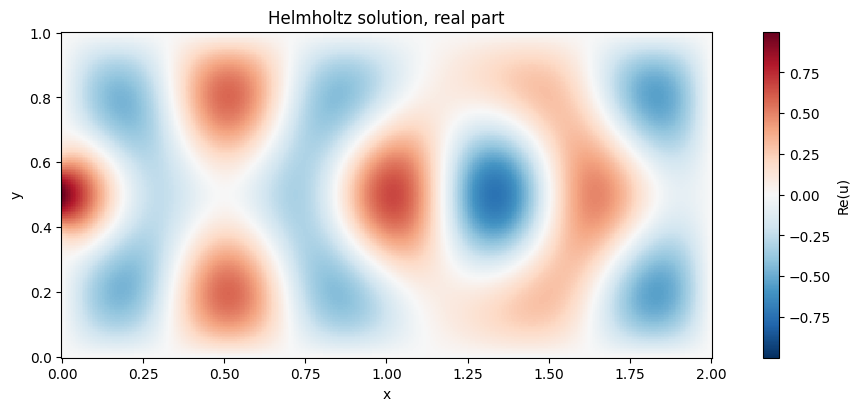

In [5]:
X, Y, solution_grid = interpolate_to_uniform_grid(
    solver, solution, points_per_leaf=33
)

field = np.real(solution_grid)
limit = np.max(np.abs(field))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
image = ax.pcolormesh(
    X, Y, field, shading="auto", cmap="RdBu_r",
    vmin=-limit, vmax=limit, rasterized=True,
)
ax.set(
    title="Helmholtz solution, real part",
    xlabel="x", ylabel="y", aspect="equal",
)
fig.colorbar(image, ax=ax, label="Re(u)")
plt.show()

The localized boundary signal produces an oscillatory field across the rectangle. To explore a different problem, change `kh`, the constant coefficient, or `boundary_data`, then rerun the build and solve cells.